In [1]:
# Jupyter: download + materialize Intel Image Classification dataset to ./archive
import sys, subprocess, zipfile, shutil
from pathlib import Path

# 1) Ensure kagglehub is available
try:
    import kagglehub  # type: ignore
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub  # type: ignore

# 2) Download to KaggleHub cache
cache_path = Path(kagglehub.dataset_download("puneet6060/intel-image-classification"))
print("KaggleHub cache:", cache_path)

# 3) Prepare local project folder
out_root = Path("archive")
out_root.mkdir(parents=True, exist_ok=True)

# Helper: extract a zip into ./archive (keeps dataset’s folder structure)
def _extract_zip(zpath: Path, dest: Path):
    with zipfile.ZipFile(zpath) as zf:
        zf.extractall(dest)

# 4) Materialize into ./archive
# Case A: cached files are zipped (common)
zip_files = list(cache_path.glob("*.zip"))
if zip_files:
    for z in zip_files:
        # Only extract if target subfolder not already present
        # seg_train.zip -> ./archive/seg_train, etc.
        guess = z.stem  # seg_train, seg_test, seg_pred
        target = out_root / guess
        if target.exists() and any(target.iterdir()):
            print(f"Skip extract: {z.name} -> {target} (already present)")
        else:
            print(f"Extracting {z.name} -> {out_root}")
            _extract_zip(z, out_root)
else:
    # Case B: cached tree is already unzipped; copy into ./archive if missing
    for name in ["seg_train", "seg_test", "seg_pred"]:
        src = cache_path / name
        if src.exists():
            dst = out_root / name
            if dst.exists() and any(dst.iterdir()):
                print(f"Skip copy: {src} -> {dst} (already present)")
            else:
                print(f"Copying {src} -> {dst}")
                shutil.copytree(src, dst, dirs_exist_ok=True)

# 5) Sanity check and report
expected = ["seg_train", "seg_test", "seg_pred"]
present = [p for p in expected if (out_root / p).exists()]
missing = [p for p in expected if p not in present]
print("\nReady root:", out_root.resolve())
print("Present:", present)
print("Missing:", missing)


KaggleHub cache: C:\Users\guang\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
Skip copy: C:\Users\guang\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train -> archive\seg_train (already present)
Skip copy: C:\Users\guang\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test -> archive\seg_test (already present)
Skip copy: C:\Users\guang\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_pred -> archive\seg_pred (already present)

Ready root: C:\Users\guang\COMP90051\A2\archive
Present: ['seg_train', 'seg_test', 'seg_pred']
Missing: []


In [2]:
# Idempotent merge: no duplicates on rerun
import os, json, shutil
from pathlib import Path
from typing import Iterable
import pandas as pd

SRC_ROOT = Path("archive")
TRAIN_DIR = SRC_ROOT / "seg_train/seg_train"
TEST_DIR  = SRC_ROOT / "seg_test/seg_test"
OUT_ROOT  = Path("merged")
IMG_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
USE_HARDLINKS = True

def iter_images(folder: Path) -> Iterable[Path]:
    if not folder.exists(): return []
    for p in folder.iterdir():
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            yield p

def deterministic_dst(split: str, cls: str, src: Path) -> Path:
    # stable name prevents duplicates across reruns
    return OUT_ROOT / cls / f"{split}_{src.name}"

def link_or_copy_if_missing(src: Path, dst: Path) -> bool:
    if dst.exists():  # already present -> skip
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    if USE_HARDLINKS:
        try:
            os.link(src, dst); return True
        except OSError:
            pass
    shutil.copy2(src, dst); return True

# classes
train_classes = {d.name for d in TRAIN_DIR.iterdir() if d.is_dir()} if TRAIN_DIR.exists() else set()
test_classes  = {d.name for d in TEST_DIR.iterdir()  if d.is_dir()} if TEST_DIR.exists()  else set()
classes = sorted(train_classes | test_classes)
assert classes, "No class folders found under archive/seg_train or archive/seg_test."
class_to_id = {c: i for i, c in enumerate(classes)}
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# merge (idempotent)
copied = skipped = 0
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    if not split_dir.exists(): continue
    for cname in classes:
        src_dir = split_dir / cname
        if not src_dir.exists(): continue
        for src in iter_images(src_dir):
            dst = deterministic_dst(split_name, cname, src)
            if link_or_copy_if_missing(src, dst):
                copied += 1
            else:
                skipped += 1

# rebuild index from merged/ to avoid duplicate rows
records = []
for cname in classes:
    cdir = OUT_ROOT / cname
    if not cdir.exists(): continue
    for p in cdir.iterdir():
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            # infer source from filename prefix if present
            fname = p.name
            source_split = "train" if fname.startswith("train_") else ("test" if fname.startswith("test_") else "unknown")
            records.append({
                "path": str(p.relative_to(OUT_ROOT).as_posix()),
                "class_id": class_to_id[cname],
                "class_name": cname,
                "source_split": source_split,
            })

df = pd.DataFrame.from_records(records).sort_values(["class_id", "source_split", "path"]).reset_index(drop=True)
OUT_ROOT.joinpath("index.csv").write_text(df.to_csv(index=False))
OUT_ROOT.joinpath("class_to_id.json").write_text(json.dumps(class_to_id, indent=2))

print("Merged root:", OUT_ROOT.resolve())
print(f"Copied: {copied}  Skipped(existing): {skipped}")
print("Wrote:", (OUT_ROOT / "index.csv").resolve())
print("Classes:", classes)
print("\nPer-class counts:\n", df.groupby("class_name")["path"].count())


Merged root: C:\Users\guang\COMP90051\A2\merged
Copied: 0  Skipped(existing): 17034
Wrote: C:\Users\guang\COMP90051\A2\merged\index.csv
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Per-class counts:
 class_name
buildings    2628
forest       2745
glacier      2957
mountain     3037
sea          2784
street       2883
Name: path, dtype: int64


In [3]:
# Sample exactly 1667 images per class from merged/<class>/* into subset_1667/<class>/*
import os, json, shutil
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd

MERGED_ROOT = Path("merged")
OUT_ROOT    = Path("subset_1667")
PER_CLASS   = 1667
SEED        = 42
USE_HARDLINKS = True
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def iter_images(folder: Path) -> list[Path]:
    return [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]

def link_or_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if USE_HARDLINKS:
        try: os.link(src, dst); return
        except OSError: pass
    shutil.copy2(src, dst)

# 1) Classes
classes = sorted([d.name for d in MERGED_ROOT.iterdir() if d.is_dir()])
assert classes, f"No class folders under {MERGED_ROOT}"
class_to_id = {c:i for i,c in enumerate(classes)}

# 2) If subset already exists with manifest, reuse it (idempotent)
manifest = OUT_ROOT / "index.csv"
if manifest.exists():
    df = pd.read_csv(manifest)
    print("Existing subset found. Skipping resample.")
else:
    rng = np.random.default_rng(SEED)
    records = []
    for cname in classes:
        src_dir = MERGED_ROOT / cname
        files = iter_images(src_dir)
        if len(files) < PER_CLASS:
            raise ValueError(f"Class '{cname}' has only {len(files)} images (< {PER_CLASS}).")
        # deterministic random sample
        sel_idx = rng.choice(len(files), size=PER_CLASS, replace=False)
        selected = [files[i] for i in sel_idx]
        for src in selected:
            dst = OUT_ROOT / cname / src.name  # stable name
            if not dst.exists():
                link_or_copy(src, dst)
            records.append({
                "path": str(dst.relative_to(OUT_ROOT).as_posix()),
                "class_id": class_to_id[cname],
                "class_name": cname,
                "source_path": str(src.as_posix()),
            })
    df = pd.DataFrame.from_records(records).sort_values(["class_id","path"]).reset_index(drop=True)
    OUT_ROOT.mkdir(parents=True, exist_ok=True)
    df.to_csv(manifest, index=False)
    with open(OUT_ROOT / "class_to_id.json", "w") as f:
        json.dump(class_to_id, f, indent=2)
    with open(OUT_ROOT / "meta.json", "w") as f:
        json.dump({"per_class": PER_CLASS, "seed": SEED}, f, indent=2)

# 3) Report
print("Subset root:", OUT_ROOT.resolve())
print("Wrote:", manifest.resolve())
print("Classes:", classes)
print("\nPer-class counts:\n", df.groupby("class_name")["path"].count())
print("\nTotal images:", len(df))


Existing subset found. Skipping resample.
Subset root: C:\Users\guang\COMP90051\A2\subset_1667
Wrote: C:\Users\guang\COMP90051\A2\subset_1667\index.csv
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Per-class counts:
 class_name
buildings    1667
forest       1667
glacier      1667
mountain     1667
sea          1667
street       1667
Name: path, dtype: int64

Total images: 10002


In [4]:
# Compute per-channel mean/std from subset_1667/<class>/* (exactly 1,667 per class)
import json
from pathlib import Path
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode as IM
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

SUBSET_ROOT = Path("subset_1667")   # created by your sampler
BASE_IMAGE_SIZE = 10
BATCH_SIZE = 256
MAX_IMAGES = None  # optional cap

assert SUBSET_ROOT.exists(), f"Missing {SUBSET_ROOT}. Run the sampling step first."

# Optional sanity: check the sampler's meta
meta_path = SUBSET_ROOT / "meta.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    assert int(meta.get("per_class", 1667)) == 1667, "Subset is not 1,667 per class."

# Dataset
ds = datasets.ImageFolder(
    root=str(SUBSET_ROOT),
    transform=transforms.Compose([
        transforms.Resize((BASE_IMAGE_SIZE, BASE_IMAGE_SIZE), interpolation=IM.BILINEAR),
        transforms.ToTensor(),  # [0,1]
    ])
)
# Verify class counts = 1667
counts = Counter(y for _, y in ds.samples)
classes = ds.classes
assert all(counts.get(i, 0) == 1667 for i in range(len(classes))), f"Classes not all 1,667: {counts}"

n_total = len(ds)
n_use = n_total if MAX_IMAGES is None else min(n_total, MAX_IMAGES)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# Running sums
total = torch.zeros(3, dtype=torch.float64)
total2 = torch.zeros(3, dtype=torch.float64)
total_pixels = 0

seen = 0
with torch.no_grad():
    for x, _ in dl:
        if seen >= n_use:
            break
        b_eff = min(x.size(0), n_use - seen)
        xb = x[:b_eff].to(dtype=torch.float64)  # [b,3,H,W] in [0,1]
        total += xb.sum(dim=[0, 2, 3])
        total2 += (xb ** 2).sum(dim=[0, 2, 3])
        total_pixels += b_eff * xb.shape[2] * xb.shape[3]
        seen += b_eff

mean = (total / total_pixels).to(dtype=torch.float32)
var = (total2 / total_pixels) - mean.to(dtype=torch.float64) ** 2
std = torch.sqrt(var.clamp(min=1e-12)).to(dtype=torch.float32)

stats = {"mean": mean.tolist(), "std": std.tolist()}
Path("artifacts").mkdir(exist_ok=True)
with open("artifacts/mean_std.json", "w") as f:
    json.dump(stats, f, indent=2)

print("Classes:", classes)
print("Images:", n_total, "Used:", seen)
print("Per-class counts: 1667 each ✓")
print("Mean:", [round(m, 4) for m in stats["mean"]])
print("Std :", [round(s, 4) for s in stats["std"]])


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Images: 10002 Used: 10002
Per-class counts: 1667 each ✓
Mean: [0.4315, 0.4574, 0.4528]
Std : [0.2179, 0.2187, 0.2567]


In [5]:
# Preprocessing + augmentations + loaders (subset_1667 only)
import json, numpy as np
from pathlib import Path
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode as IM
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

SUBSET_ROOT = "subset_1667"   # use only the sampled subset
VAL_RATIO = 0.2
SEED = 42

with open("artifacts/mean_std.json") as f:
    ms = json.load(f)
MEAN, STD = ms["mean"], ms["std"]

class AddGaussianNoise:
    def __init__(self, sigma=0.05): self.sigma = float(sigma)
    def __call__(self, t):
        if not torch.is_tensor(t): return t
        return (t + torch.randn_like(t) * self.sigma).clamp(0, 1)

# -------- transforms (use these names in all future scripts) --------
train_tfms = transforms.Compose([
    transforms.Resize((BASE_IMAGE_SIZE, BASE_IMAGE_SIZE), interpolation=IM.BILINEAR),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
    transforms.ToTensor(),
    AddGaussianNoise(sigma=0.05),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing(p=0.5, scale=(0.10, 0.20), ratio=(0.5, 2.0)),
])

eval_tfms = transforms.Compose([
    transforms.Resize((BASE_IMAGE_SIZE, BASE_IMAGE_SIZE), interpolation=IM.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

robust_tfms = {
    "occlusion": transforms.Compose([
        transforms.Resize((BASE_IMAGE_SIZE, BASE_IMAGE_SIZE), interpolation=IM.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
        transforms.RandomErasing(p=1.0, scale=(0.20, 0.40), ratio=(0.5, 2.0)),
    ]),
    "lighting": transforms.Compose([
        transforms.Resize((BASE_IMAGE_SIZE, BASE_IMAGE_SIZE), interpolation=IM.BILINEAR),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    "view": transforms.Compose([
        transforms.Resize((BASE_IMAGE_SIZE, BASE_IMAGE_SIZE), interpolation=IM.BILINEAR),
        transforms.RandomRotation(25),
        transforms.RandomPerspective(distortion_scale=0.1, p=1.0, interpolation=IM.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
}

# -------- datasets and loaders (subset_1667 only) --------
# fixed stratified 80/20 split
base = datasets.ImageFolder(SUBSET_ROOT, transform=None)
classes = base.classes
K = len(classes)
idxs = np.arange(len(base))
y_all = np.array([y for _, y in base.samples], dtype=np.int64)

train_idx, val_idx = [], []
for c in range(K):
    c_idx = idxs[y_all == c]
    rng = np.random.default_rng(SEED + c)
    rng.shuffle(c_idx)
    cut = int(len(c_idx) * (1 - VAL_RATIO))
    train_idx.extend(c_idx[:cut]); val_idx.extend(c_idx[cut:])
train_idx, val_idx = np.array(train_idx), np.array(val_idx)

train_ds = Subset(datasets.ImageFolder(SUBSET_ROOT, transform=train_tfms), train_idx)
val_ds   = Subset(datasets.ImageFolder(SUBSET_ROOT, transform=eval_tfms),  val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# optional: robustness loaders built on the SAME val split
robust_loaders = {
    name: DataLoader(Subset(datasets.ImageFolder(SUBSET_ROOT, transform=tfm), val_idx),
                     batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    for name, tfm in robust_tfms.items()
}

print("Classes:", classes)
print("Train batches:", len(train_loader), "Val batches:", len(val_loader))


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train batches: 32 Val batches: 8


In [6]:
def plot_confusion_matrix(cm, classes, title):
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0)
    ax.set(
        xticks=np.arange(len(classes)), yticks=np.arange(len(classes)),
        xticklabels=classes, yticklabels=classes,
        xlabel="Predicted", ylabel="True"
    )
    ax.set_title(title, pad=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    fig.colorbar(im, cax=cax)

    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]),
                    ha="center", va="center",
                    color=("white" if cm[i, j] > thresh else "black"), fontsize=9)

    fig.tight_layout()
    plt.show()


=== Outer fold 1/10 ===
  inner grid: PCA=16 vs=1e-04 -> f1m=0.5343
  inner grid: PCA=16 vs=1e-03 -> f1m=0.5324
  inner grid: PCA=16 vs=1e-02 -> f1m=0.5330
  inner grid: PCA=32 vs=1e-04 -> f1m=0.5534
  inner grid: PCA=32 vs=1e-03 -> f1m=0.5562
  inner grid: PCA=32 vs=1e-02 -> f1m=0.5366
  inner grid: PCA=64 vs=1e-04 -> f1m=0.5352
  inner grid: PCA=64 vs=1e-03 -> f1m=0.5428
  inner grid: PCA=64 vs=1e-02 -> f1m=0.5389
Chosen (outer fold 1): {'pca': 32, 'var_smoothing': 0.001} from inner-CV f1m=0.5562
Outer fold 1: acc=0.5554  f1m=0.5411
  [Robust:occlusion] acc=0.4605  f1m=0.4529
  [Robust:lighting] acc=0.4845  f1m=0.4692
  [Robust:view] acc=0.4466  f1m=0.4526

=== Outer fold 2/10 ===
  inner grid: PCA=16 vs=1e-04 -> f1m=0.5344
  inner grid: PCA=16 vs=1e-03 -> f1m=0.5318
  inner grid: PCA=16 vs=1e-02 -> f1m=0.5303
  inner grid: PCA=32 vs=1e-04 -> f1m=0.5501
  inner grid: PCA=32 vs=1e-03 -> f1m=0.5528
  inner grid: PCA=32 vs=1e-02 -> f1m=0.5322
  inner grid: PCA=64 vs=1e-04 -> f1m=0.5235

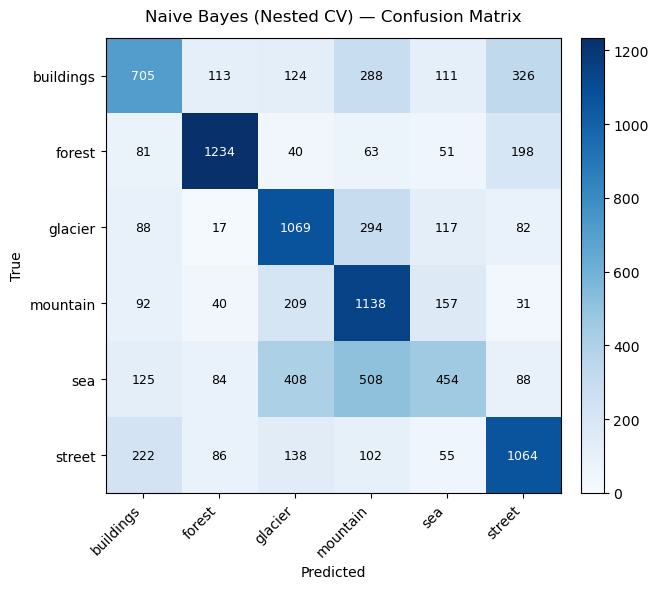

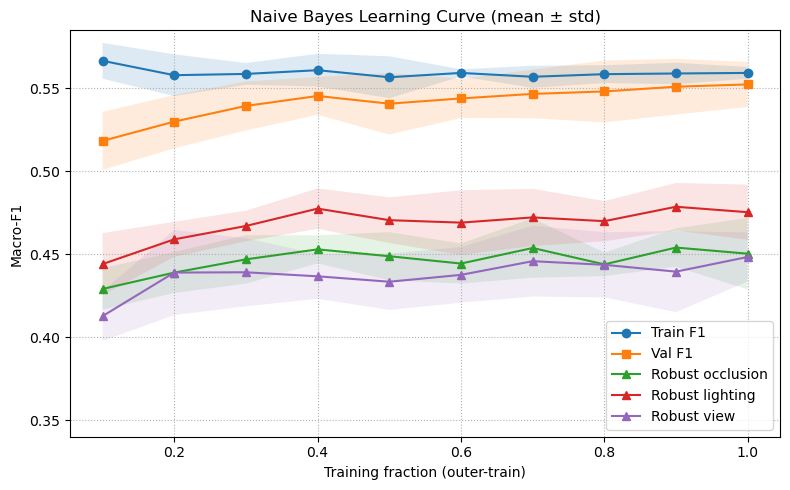

In [7]:
# Nested CV (10×3) for PCA -> GaussianNB with train/eval/robust transforms
# - Outer 10-fold: report performance on each outer-val
# - Inner 3-fold: select hyperparams (PCA components, var_smoothing) using outer-train only
# - Uses train_tfms on training folds, eval_tfms on validation folds, robust_tfms on robustness tests
# - Outputs: per-fold metrics, aggregate metrics, classification report, confusion matrix, learning curve

import os, json, time, math, itertools, numpy as np, torch
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold

from torch.utils.data import DataLoader, Subset
from torchvision import datasets

# -------- prerequisites from your preprocessing cell --------
assert "train_tfms" in globals() and "eval_tfms" in globals(), "Define train_tfms and eval_tfms first."
if "robust_tfms" not in globals(): robust_tfms = {}  # optional

# Prefer using the same root/classes as your existing datasets if present
if "train_ds" in globals():
    base_root = getattr(getattr(train_ds, "dataset", train_ds), "root", None)
else:
    base_root = "subset_1667" if Path("subset_1667").exists() else "merged"
assert base_root and Path(base_root).exists(), f"Base dataset root not found: {base_root}"

base = datasets.ImageFolder(base_root, transform=None)
classes = base.classes
K = len(classes)
y_all = np.array([y for _, y in base.samples], dtype=np.int64)
N = len(base)
idx_all = np.arange(N)

# ---------------- config ----------------
SEED = 42
OUTER_FOLDS = 10
INNER_FOLDS = 3
BATCH_SIZE = 256
NUM_WORKERS = 0
PCA_SAMPLE_MAX = 10_000

# modest grids to keep runtime sane
GRID_PCA = [16, 32, 64]
GRID_VS  = [1e-4, 1e-3, 1e-2]

LEARNING_FRACTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # outer-train subsample sizes for learning curve

# ---------------- utils ----------------
def seed_all(s=SEED):
    os.environ["PYTHONHASHSEED"] = str(s)
    np.random.seed(s); torch.manual_seed(s)
seed_all()

def make_loader(indices, tfm, shuffle):
    ds = Subset(datasets.ImageFolder(base_root, transform=tfm), indices)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=False)

@torch.no_grad()
def flat_batches(loader):
    for xb, yb in loader:
        yield xb.view(xb.size(0), -1).cpu().numpy().astype(np.float32), yb.cpu().numpy()

def collect_Xy(loader):
    Xs, ys = [], []
    for Xb, yb in flat_batches(loader):
        Xs.append(Xb); ys.append(yb)
    return np.concatenate(Xs, 0), np.concatenate(ys, 0)

def fit_pca(Xtr, n_components, max_fit=PCA_SAMPLE_MAX, seed=SEED):
    if max_fit is not None and len(Xtr) > max_fit:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xtr), size=max_fit, replace=False)
        Xfit = Xtr[idx]
    else:
        Xfit = Xtr
    pca = PCA(n_components=n_components, svd_solver="randomized", random_state=seed)
    pca.fit(Xfit)
    return pca

def stratified_subsample(indices, labels, frac, seed=SEED):
    if frac >= 1.0: return indices
    rng = np.random.default_rng(seed)
    take = []
    lab = labels[indices]
    for c in range(K):
        c_idx = indices[lab == c]
        n = max(1, int(math.ceil(len(c_idx) * frac)))
        if len(c_idx) == 0: continue
        pick = rng.choice(c_idx, size=min(n, len(c_idx)), replace=False)
        take.append(pick)
    return np.sort(np.concatenate(take, 0))

def eval_loader_with(pca, gnb, loader):
    y_true, y_pred = [], []
    for Xb, yb in flat_batches(loader):
        y_true.append(yb)
        y_pred.append(gnb.predict(pca.transform(Xb)))
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return acc, f1m, y_true, y_pred

def plot_cm(cm, classes, title):
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, interpolation="nearest")  # default colormap
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(len(classes)), yticks=np.arange(len(classes)),
           xticklabels=classes, yticklabels=classes,
           ylabel="True", xlabel="Predicted", title=title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for i, j in itertools.product(range(len(classes)), range(len(classes))):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.tight_layout(); plt.show()

# ---------------- nested CV ----------------
outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

outer_metrics = []               # per-fold dicts
outer_preds_all = []             # concatenate for final report
outer_true_all  = []
robust_metrics = defaultdict(list)  # name -> list of (acc, f1m) over folds

# ---- learning-curve accumulators (train + val + robust) ----
lc_train_scores = {f: [] for f in LEARNING_FRACTIONS}
lc_val_scores   = {f: [] for f in LEARNING_FRACTIONS}
lc_robust_scores = {name: {f: [] for f in LEARNING_FRACTIONS} for name in robust_tfms.keys()}

fold_id = 0
for outer_tr_idx, outer_va_idx in outer_cv.split(idx_all, y_all):
    fold_id += 1
    print(f"\n=== Outer fold {fold_id}/{OUTER_FOLDS} ===")

    # ----- inner CV to choose hyperparams -----
    inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=SEED + fold_id)
    best_cfg, best_score = None, -1.0

    for n_comp in GRID_PCA:
        for vs in GRID_VS:
            scores = []
            for inner_tr_rel, inner_va_rel in inner_cv.split(outer_tr_idx, y_all[outer_tr_idx]):
                inner_tr_idx = outer_tr_idx[inner_tr_rel]
                inner_va_idx = outer_tr_idx[inner_va_rel]
                # loaders with proper transforms
                tr_loader = make_loader(inner_tr_idx, train_tfms, shuffle=True)
                va_loader = make_loader(inner_va_idx, eval_tfms,  shuffle=False)
                # collect arrays
                Xtr, ytr = collect_Xy(tr_loader)
                Xva, yva = collect_Xy(va_loader)
                # fit PCA on inner-train, then NB
                pca = fit_pca(Xtr, n_components=n_comp, max_fit=PCA_SAMPLE_MAX, seed=SEED)
                Ztr = pca.transform(Xtr)
                clf = GaussianNB(var_smoothing=vs).fit(Ztr, ytr)
                # eval
                f1m = f1_score(yva, clf.predict(pca.transform(Xva)), average="macro")
                scores.append(f1m)
            mean_f1 = float(np.mean(scores))
            print(f"  inner grid: PCA={n_comp} vs={vs:.0e} -> f1m={mean_f1:.4f}")
            if mean_f1 > best_score:
                best_score = mean_f1
                best_cfg = {"pca": n_comp, "var_smoothing": vs}

    print(f"Chosen (outer fold {fold_id}): {best_cfg} from inner-CV f1m={best_score:.4f}")

    # ----- train on full outer-train with best hyperparams -----
    tr_loader = make_loader(outer_tr_idx, train_tfms, shuffle=True)
    va_loader = make_loader(outer_va_idx, eval_tfms,  shuffle=False)
    Xtr, ytr = collect_Xy(tr_loader)
    Xva, yva = collect_Xy(va_loader)

    pca = fit_pca(Xtr, n_components=best_cfg["pca"], max_fit=PCA_SAMPLE_MAX, seed=SEED)
    clf = GaussianNB(var_smoothing=best_cfg["var_smoothing"]).fit(pca.transform(Xtr), ytr)

    acc, f1m, y_true, y_pred = eval_loader_with(pca, clf, va_loader)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"Outer fold {fold_id}: acc={acc:.4f}  f1m={f1m:.4f}")
    outer_metrics.append({"fold": fold_id, "acc": acc, "f1m": f1m, "prec": prec, "rec": rec, **best_cfg})
    outer_true_all.append(y_true); outer_preds_all.append(y_pred)

    # ----- robustness on outer-val with robust_tfms -----
    for name, tfm in robust_tfms.items():
        r_loader = make_loader(outer_va_idx, tfm, shuffle=False)
        racc, rf1, _, _ = eval_loader_with(pca, clf, r_loader)
        robust_metrics[name].append((racc, rf1))
        print(f"  [Robust:{name}] acc={racc:.4f}  f1m={rf1:.4f}")

    # ----- learning curve on outer fold (fixed best hyperparams) -----
    for frac in LEARNING_FRACTIONS:
        sub_idx = stratified_subsample(outer_tr_idx, y_all, frac, seed=SEED + fold_id + int(frac*1000))

        # train subset with train_tfms
        lc_tr_loader = make_loader(sub_idx, train_tfms, shuffle=True)
        Xlc, ylc = collect_Xy(lc_tr_loader)

        pca_lc = fit_pca(Xlc, n_components=best_cfg["pca"], max_fit=PCA_SAMPLE_MAX, seed=SEED)
        clf_lc = GaussianNB(var_smoothing=best_cfg["var_smoothing"]).fit(pca_lc.transform(Xlc), ylc)

        # train F1 (clean preprocessing on the same subset)
        train_eval_loader = make_loader(sub_idx, eval_tfms, shuffle=False)
        _, f1_train, _, _ = eval_loader_with(pca_lc, clf_lc, train_eval_loader)

        # val F1 on this fold's outer validation
        _, f1_val, _, _ = eval_loader_with(pca_lc, clf_lc, va_loader)

        lc_train_scores[frac].append(f1_train)
        lc_val_scores[frac].append(f1_val)

        # robustness F1s on outer validation
        for rname, rtfm in robust_tfms.items():
            r_loader = make_loader(outer_va_idx, rtfm, shuffle=False)
            _, f1_r, _, _ = eval_loader_with(pca_lc, clf_lc, r_loader)
            lc_robust_scores[rname][frac].append(f1_r)

# ---------------- aggregate results ----------------
y_all_val = np.concatenate(outer_true_all)
y_all_pred = np.concatenate(outer_preds_all)

mean_acc = np.mean([m["acc"] for m in outer_metrics])
std_acc  = np.std([m["acc"] for m in outer_metrics])
mean_f1  = np.mean([m["f1m"] for m in outer_metrics])
std_f1   = np.std([m["f1m"] for m in outer_metrics])

# precision/recall stats and standard errors
precisions = np.array([m["prec"] for m in outer_metrics], dtype=float)
recalls    = np.array([m["rec"]  for m in outer_metrics], dtype=float)
k = len(precisions)

mean_prec = float(np.mean(precisions))
std_prec  = float(np.std(precisions, ddof=1))        # sample std
se_prec   = float(std_prec / np.sqrt(k))

mean_rec  = float(np.mean(recalls))
std_rec   = float(np.std(recalls, ddof=1))           # sample std
se_rec    = float(std_rec / np.sqrt(k))

print("\n=== Nested CV summary (outer folds) ===")
print(f"Accuracy        mean={mean_acc:.4f}  std={std_acc:.4f}")
print(f"Macro-F1        mean={mean_f1:.4f}  std={std_f1:.4f}")
print(f"Macro-Precision mean={mean_prec:.4f} std={std_prec:.4f} se={se_prec:.4f}")
print(f"Macro-Recall    mean={mean_rec:.4f}  std={std_rec:.4f}  se={se_rec:.4f}")

print("\nPer-fold results:")
for m in outer_metrics:
    print(f" fold {m['fold']:02d}: acc={m['acc']:.4f} f1m={m['f1m']:.4f} | PCA={m['pca']} vs={m['var_smoothing']:.0e}")

# Robustness summary
if robust_metrics:
    print("\nRobustness (outer-val) summary:")
    for name, vals in robust_metrics.items():
        accs = [a for a, _ in vals]; f1s = [f for _, f in vals]
        print(f" {name:<10} acc mean={np.mean(accs):.4f} std={np.std(accs):.4f} | f1 mean={np.mean(f1s):.4f} std={np.std(f1s):.4f}")

# Final classification report over concatenated outer validations
print("\nClassification report (all outer validations):")
print(classification_report(y_all_val, y_all_pred, target_names=classes, digits=4))

# Confusion matrix over all outer validations
cm = confusion_matrix(y_all_val, y_all_pred)
plot_confusion_matrix(cm, classes, "Naive Bayes (Nested CV) — Confusion Matrix")

# ---- learning curve: train + val + robust with error bands ----
fracs = np.array(LEARNING_FRACTIONS, dtype=float)

t_means = np.array([np.mean(lc_train_scores[f]) for f in fracs])
t_stds  = np.array([np.std( lc_train_scores[f]) for f in fracs])
v_means = np.array([np.mean(lc_val_scores[f])   for f in fracs])
v_stds  = np.array([np.std( lc_val_scores[f])   for f in fracs])

plt.figure(figsize=(8,5))
plt.plot(fracs, t_means, marker="o", label="Train F1")
plt.fill_between(fracs, t_means - t_stds, t_means + t_stds, alpha=0.15)

plt.plot(fracs, v_means, marker="s", label="Val F1")
plt.fill_between(fracs, v_means - v_stds, v_means + v_stds, alpha=0.15)

for rname, per_frac in lc_robust_scores.items():
    r_means = np.array([np.mean(per_frac[f]) for f in fracs])
    r_stds  = np.array([np.std( per_frac[f]) for f in fracs])
    plt.plot(fracs, r_means, marker="^", label=f"Robust {rname}")
    plt.fill_between(fracs, r_means - r_stds, r_means + r_stds, alpha=0.12)

plt.xlabel("Training fraction (outer-train)")
plt.ylabel("Macro-F1")
plt.title("Naive Bayes Learning Curve (mean ± std)")
plt.ylim(0.34, 0.585)
plt.grid(True, linestyle=":")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------- optional: save artifacts ----------------
Path("artifacts").mkdir(exist_ok=True)

robust_lc = {
    name: {
        "fractions": fracs.tolist(),
        "mean_macro_f1": [float(np.mean(per_frac[f])) for f in fracs],
        "std_macro_f1":  [float(np.std( per_frac[f])) for f in fracs],
    }
    for name, per_frac in lc_robust_scores.items()
}

with open("artifacts/nb_nestedcv_summary.json", "w") as f:
    json.dump({
        "outer_folds": OUTER_FOLDS,
        "inner_folds": INNER_FOLDS,
        "grid": {"pca": GRID_PCA, "var_smoothing": GRID_VS},
        "outer_metrics": outer_metrics,  # now includes prec/rec per fold
        "accuracy": {"mean": float(mean_acc), "std": float(std_acc)},
        "macro_f1": {"mean": float(mean_f1), "std": float(std_f1)},
        "macro_precision": {"mean": mean_prec, "std": std_prec, "se": se_prec},
        "macro_recall":    {"mean": mean_rec,  "std": std_rec,  "se": se_rec},
        "learning_curve": {
            "fractions": fracs.tolist(),
            "train_mean_macro_f1": t_means.tolist(),
            "train_std_macro_f1":  t_stds.tolist(),
            "val_mean_macro_f1":   v_means.tolist(),
            "val_std_macro_f1":    v_stds.tolist()
        },
        "robust_learning_curves": robust_lc
    }, f, indent=2)




=== Outer fold 1/10 ===
  inner grid: PCA=16 C=0.1 -> f1m=0.5612
  inner grid: PCA=16 C=1 -> f1m=0.5898
  inner grid: PCA=16 C=10 -> f1m=0.5495
  inner grid: PCA=32 C=0.1 -> f1m=0.5408
  inner grid: PCA=32 C=1 -> f1m=0.6237
  inner grid: PCA=32 C=10 -> f1m=0.5876
  inner grid: PCA=64 C=0.1 -> f1m=0.4452
  inner grid: PCA=64 C=1 -> f1m=0.6011
  inner grid: PCA=64 C=10 -> f1m=0.5824
Chosen (outer fold 1): {'pca': 32, 'C': 1} from inner-CV f1m=0.6237
Outer fold 1: acc=0.6633  f1m=0.6623
  [Robust:occlusion] acc=0.5385  f1m=0.5442
  [Robust:lighting] acc=0.5974  f1m=0.5963
  [Robust:view] acc=0.5504  f1m=0.5535

=== Outer fold 2/10 ===
  inner grid: PCA=16 C=0.1 -> f1m=0.5533
  inner grid: PCA=16 C=1 -> f1m=0.5870
  inner grid: PCA=16 C=10 -> f1m=0.5434
  inner grid: PCA=32 C=0.1 -> f1m=0.5304
  inner grid: PCA=32 C=1 -> f1m=0.6175
  inner grid: PCA=32 C=10 -> f1m=0.5810
  inner grid: PCA=64 C=0.1 -> f1m=0.4594
  inner grid: PCA=64 C=1 -> f1m=0.6060
  inner grid: PCA=64 C=10 -> f1m=0.5788

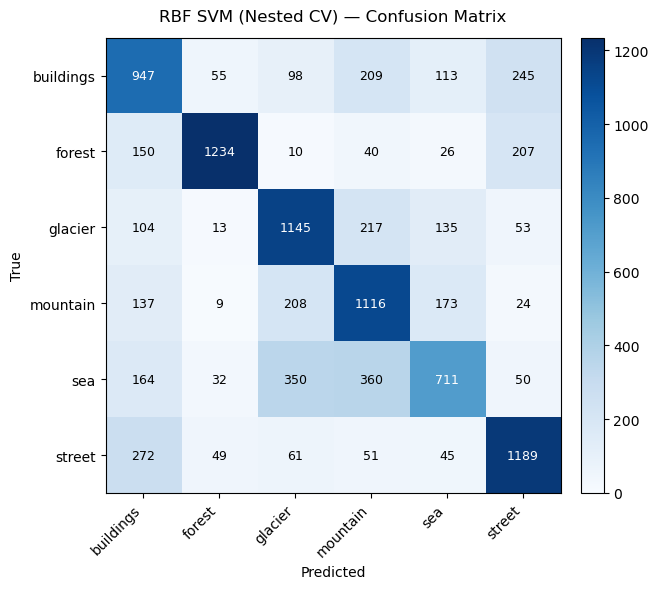

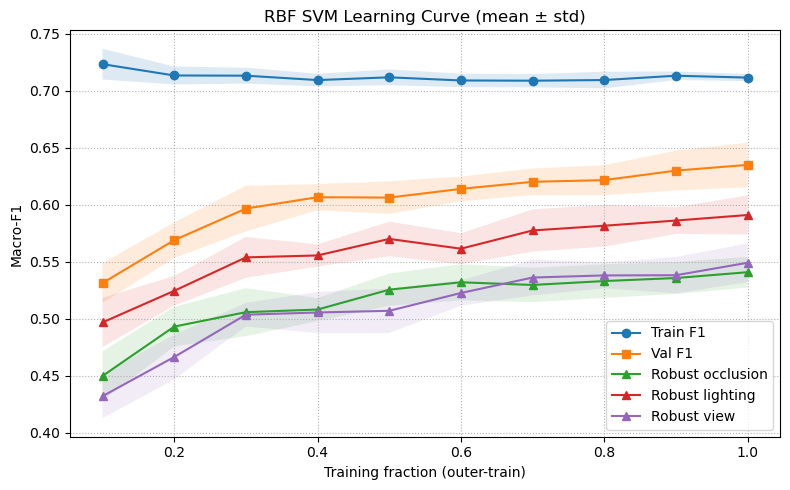

In [7]:
# Nested CV (10×3) for PCA -> RBF SVM with train/eval/robust transforms
# - Outer 10-fold: report performance on each outer-val
# - Inner 3-fold: select hyperparams (PCA components, C) using only outer-train
# - train_tfms on training folds, eval_tfms on validation folds, robust_tfms on robustness tests
# - Outputs: per-fold metrics, aggregate metrics, classification report, confusion matrix, learning curve

import os, json, time, math, itertools, numpy as np, torch
from pathlib import Path
from collections import defaultdict
from typing import Dict, List

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold

from torch.utils.data import DataLoader, Subset
from torchvision import datasets

# ----- prerequisites from your preprocessing cell -----
assert "train_tfms" in globals() and "eval_tfms" in globals(), "Define train_tfms and eval_tfms first."
if "robust_tfms" not in globals(): robust_tfms = {}  # optional

# Use same root/classes as your existing datasets if present
if "train_ds" in globals():
    base_root = getattr(getattr(train_ds, "dataset", train_ds), "root", None)
else:
    base_root = "subset_1667" if Path("subset_1667").exists() else "merged"
assert base_root and Path(base_root).exists(), f"Base dataset root not found: {base_root}"

base = datasets.ImageFolder(base_root, transform=None)
classes = base.classes
K = len(classes)
y_all = np.array([y for _, y in base.samples], dtype=np.int64)
N = len(base)
idx_all = np.arange(N)

# ----- config -----
SEED = 42
OUTER_FOLDS = 10
INNER_FOLDS = 3
BATCH_SIZE = 256
NUM_WORKERS = 0
PCA_SAMPLE_MAX = 10_000

GRID_PCA = [16, 32, 64]   # hyperparam 1
GRID_C   = [0.1, 1, 10]   # hyperparam 2
LEARNING_FRACTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# ----- utils -----
def seed_all(s=SEED):
    os.environ["PYTHONHASHSEED"] = str(s)
    np.random.seed(s); torch.manual_seed(s)
seed_all()

def make_loader(indices, tfm, shuffle):
    ds = Subset(datasets.ImageFolder(base_root, transform=tfm), indices)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=False)

@torch.no_grad()
def flat_batches(loader):
    for xb, yb in loader:
        yield xb.view(xb.size(0), -1).cpu().numpy().astype(np.float32), yb.cpu().numpy()

def collect_Xy(loader):
    Xs, ys = [], []
    for Xb, yb in flat_batches(loader):
        Xs.append(Xb); ys.append(yb)
    return np.concatenate(Xs, 0), np.concatenate(ys, 0)

def fit_pca(Xtr, n_components, max_fit=PCA_SAMPLE_MAX, seed=SEED):
    if max_fit is not None and len(Xtr) > max_fit:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xtr), size=max_fit, replace=False)
        Xfit = Xtr[idx]
    else:
        Xfit = Xtr
    pca = PCA(n_components=n_components, svd_solver="randomized", random_state=seed)
    pca.fit(Xfit)
    return pca

def eval_loader_with(pca, scaler, clf, loader):
    y_true, y_pred = [], []
    for Xb, yb in flat_batches(loader):
        Zb = pca.transform(Xb)
        Zb = scaler.transform(Zb)
        y_true.append(yb)
        y_pred.append(clf.predict(Zb))
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return acc, f1m, y_true, y_pred

def stratified_subsample(indices, labels, frac, seed=SEED):
    if frac >= 1.0: return indices
    rng = np.random.default_rng(seed)
    take = []
    lab = labels[indices]
    for c in range(K):
        c_idx = indices[lab == c]
        if len(c_idx) == 0: continue
        n = max(1, int(math.ceil(len(c_idx) * frac)))
        pick = rng.choice(c_idx, size=min(n, len(c_idx)), replace=False)
        take.append(pick)
    return np.sort(np.concatenate(take, 0))

def plot_cm(cm, classes, title):
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(len(classes)), yticks=np.arange(len(classes)),
           xticklabels=classes, yticklabels=classes,
           ylabel="True", xlabel="Predicted", title=title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for i, j in itertools.product(range(len(classes)), range(len(classes))):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.tight_layout(); plt.show()

# ----- nested CV -----
outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

outer_metrics = []
outer_preds_all = []
outer_true_all  = []
robust_metrics = defaultdict(list)

# ----- learning curve: train+val F1 with error bands -----
fracs = np.array(LEARNING_FRACTIONS, dtype=float)
lc_train_scores = {f: [] for f in LEARNING_FRACTIONS}
lc_val_scores   = {f: [] for f in LEARNING_FRACTIONS}
lc_robust_scores = {name: {f: [] for f in LEARNING_FRACTIONS} for name in robust_tfms.keys()}

for fold_id, (outer_tr_idx, outer_va_idx) in enumerate(outer_cv.split(idx_all, y_all), 1):
    print(f"\n=== Outer fold {fold_id}/{OUTER_FOLDS} ===")
    # inner CV
    inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=SEED + fold_id)
    best_cfg, best_score = None, -1.0

    for n_comp in GRID_PCA:
        for Cval in GRID_C:
            scores = []
            for inner_tr_rel, inner_va_rel in inner_cv.split(outer_tr_idx, y_all[outer_tr_idx]):
                inner_tr = outer_tr_idx[inner_tr_rel]
                inner_va = outer_tr_idx[inner_va_rel]
                tr_loader = make_loader(inner_tr, train_tfms, shuffle=True)
                va_loader = make_loader(inner_va, eval_tfms,  shuffle=False)
                Xtr, ytr = collect_Xy(tr_loader)
                Xva, yva = collect_Xy(va_loader)

                pca = fit_pca(Xtr, n_components=n_comp, max_fit=PCA_SAMPLE_MAX, seed=SEED)
                Ztr = pca.transform(Xtr)
                scaler = StandardScaler(with_mean=True, with_std=True).fit(Ztr)
                Ztr_s = scaler.transform(Ztr)

                clf = SVC(C=Cval, kernel="rbf", gamma="scale", class_weight=None, random_state=SEED)
                clf.fit(Ztr_s, ytr)

                f1m = f1_score(yva, clf.predict(scaler.transform(pca.transform(Xva))), average="macro")
                scores.append(f1m)

            mean_f1 = float(np.mean(scores))
            print(f"  inner grid: PCA={n_comp} C={Cval} -> f1m={mean_f1:.4f}")
            if mean_f1 > best_score:
                best_score = mean_f1
                best_cfg = {"pca": n_comp, "C": Cval}

    print(f"Chosen (outer fold {fold_id}): {best_cfg} from inner-CV f1m={best_score:.4f}")

    # train on full outer-train with best hyperparams
    tr_loader = make_loader(outer_tr_idx, train_tfms, shuffle=True)
    va_loader = make_loader(outer_va_idx, eval_tfms,  shuffle=False)
    Xtr, ytr = collect_Xy(tr_loader)
    Xva, yva = collect_Xy(va_loader)

    pca = fit_pca(Xtr, n_components=best_cfg["pca"], max_fit=PCA_SAMPLE_MAX, seed=SEED)
    Ztr = pca.transform(Xtr)
    scaler = StandardScaler(with_mean=True, with_std=True).fit(Ztr)
    Ztr_s = scaler.transform(Ztr)

    clf = SVC(C=best_cfg["C"], kernel="rbf", gamma="scale", class_weight=None, random_state=SEED)
    clf.fit(Ztr_s, ytr)

    acc, f1m, y_true, y_pred = eval_loader_with(pca, scaler, clf, va_loader)
    print(f"Outer fold {fold_id}: acc={acc:.4f}  f1m={f1m:.4f}")
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(  y_true, y_pred, average="macro", zero_division=0)
    outer_metrics.append({"fold": fold_id, "acc": acc, "f1m": f1m, "prec": prec, "rec": rec, **best_cfg})
    outer_true_all.append(y_true); outer_preds_all.append(y_pred)

    # robustness on outer-val
    for name, tfm in robust_tfms.items():
        r_loader = make_loader(outer_va_idx, tfm, shuffle=False)
        racc, rf1, _, _ = eval_loader_with(pca, scaler, clf, r_loader)
        robust_metrics[name].append((racc, rf1))
        print(f"  [Robust:{name}] acc={racc:.4f}  f1m={rf1:.4f}")

    # learning curve on outer fold
    va_loader = make_loader(outer_va_idx, eval_tfms, shuffle=False)

    for frac in fracs:
        sub_idx = stratified_subsample(outer_tr_idx, y_all, float(frac),
                                       seed=SEED + fold_id + int(frac*1000))
        lc_tr_loader = make_loader(sub_idx, train_tfms, shuffle=True)
        Xlc, ylc = collect_Xy(lc_tr_loader)

        pca_lc = fit_pca(Xlc, n_components=best_cfg["pca"], max_fit=PCA_SAMPLE_MAX, seed=SEED)
        Zlc = pca_lc.transform(Xlc)
        scaler_lc = StandardScaler(with_mean=True, with_std=True).fit(Zlc)
        clf_lc = SVC(C=best_cfg["C"], kernel="rbf", gamma="scale", class_weight=None, random_state=SEED)
        clf_lc.fit(scaler_lc.transform(Zlc), ylc)

        train_eval_loader = make_loader(sub_idx, eval_tfms, shuffle=False)
        _, f1_train, _, _ = eval_loader_with(pca_lc, scaler_lc, clf_lc, train_eval_loader)
        _, f1_val,   _, _ = eval_loader_with(pca_lc, scaler_lc, clf_lc, va_loader)

        key = float(frac)
        lc_train_scores[key].append(f1_train)
        lc_val_scores[key].append(f1_val)

        # robustness on outer-val at this fraction
        for rname, rtfm in robust_tfms.items():
            r_loader = make_loader(outer_va_idx, rtfm, shuffle=False)
            _, f1_r, _, _ = eval_loader_with(pca_lc, scaler_lc, clf_lc, r_loader)
            lc_robust_scores[rname][key].append(f1_r)


# ----- aggregate results -----
y_all_val = np.concatenate(outer_true_all)
y_all_pred = np.concatenate(outer_preds_all)

mean_acc = np.mean([m["acc"] for m in outer_metrics])
std_acc  = np.std([m["acc"] for m in outer_metrics])
mean_f1  = np.mean([m["f1m"] for m in outer_metrics])
std_f1   = np.std([m["f1m"] for m in outer_metrics])

precisions = np.array([m["prec"] for m in outer_metrics], float)
recalls    = np.array([m["rec"]  for m in outer_metrics], float)
k = len(precisions)

mean_prec = float(np.mean(precisions))
std_prec  = float(np.std(precisions, ddof=1))
se_prec   = float(std_prec / np.sqrt(k))

mean_rec  = float(np.mean(recalls))
std_rec   = float(np.std(recalls, ddof=1))
se_rec    = float(std_rec / np.sqrt(k))

print("\n=== Nested CV summary (outer folds) ===")
print(f"Accuracy        mean={mean_acc:.4f}  std={std_acc:.4f}")
print(f"Macro-F1        mean={mean_f1:.4f}  std={std_f1:.4f}")
print(f"Macro-Precision mean={mean_prec:.4f} std={std_prec:.4f} se={se_prec:.4f}")
print(f"Macro-Recall    mean={mean_rec:.4f}  std={std_rec:.4f}  se={se_rec:.4f}")

print("\nPer-fold results:")
for m in outer_metrics:
    print(f" fold {m['fold']:02d}: acc={m['acc']:.4f} f1m={m['f1m']:.4f} | PCA={m['pca']} C={m['C']}")

if robust_metrics:
    print("\nRobustness (outer-val) summary:")
    for name, vals in robust_metrics.items():
        accs = [a for a, _ in vals]; f1s = [f for _, f in vals]
        print(f" {name:<10} acc mean={np.mean(accs):.4f} std={np.std(accs):.4f} | f1 mean={np.mean(f1s):.4f} std={np.std(f1s):.4f}")

print("\nClassification report (all outer validations):")
print(classification_report(y_all_val, y_all_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_all_val, y_all_pred)
plot_confusion_matrix(cm, classes, "RBF SVM (Nested CV) — Confusion Matrix")

# ----- learning curve with error bands (train, val, robust) -----
t_means = np.array([np.mean(lc_train_scores[f]) for f in LEARNING_FRACTIONS])
t_stds  = np.array([np.std( lc_train_scores[f]) for f in LEARNING_FRACTIONS])
v_means = np.array([np.mean(lc_val_scores[f])   for f in LEARNING_FRACTIONS])
v_stds  = np.array([np.std( lc_val_scores[f])   for f in LEARNING_FRACTIONS])

plt.figure(figsize=(8,5))
plt.plot(fracs, t_means, marker="o", label="Train F1")
plt.fill_between(fracs, t_means - t_stds, t_means + t_stds, alpha=0.15)
plt.plot(fracs, v_means, marker="s", label="Val F1")
plt.fill_between(fracs, v_means - v_stds, v_means + v_stds, alpha=0.15)

for rname, per_frac in lc_robust_scores.items():
    r_means = np.array([np.mean(per_frac[f]) for f in LEARNING_FRACTIONS])
    r_stds  = np.array([np.std( per_frac[f]) for f in LEARNING_FRACTIONS])
    plt.plot(fracs, r_means, marker="^", label=f"Robust {rname}")
    plt.fill_between(fracs, r_means - r_stds, r_means + r_stds, alpha=0.12)

plt.xlabel("Training fraction (outer-train)")
plt.ylabel("Macro-F1")
plt.title("RBF SVM Learning Curve (mean ± std)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()


# ----- save summary -----
Path("artifacts").mkdir(exist_ok=True)

robust_lc = {
    name: {
        "fractions": LEARNING_FRACTIONS,
        "mean_macro_f1": [float(np.mean(per_frac[f])) for f in LEARNING_FRACTIONS],
        "std_macro_f1":  [float(np.std( per_frac[f])) for f in LEARNING_FRACTIONS],
    }
    for name, per_frac in lc_robust_scores.items()
}

with open("artifacts/svm_rbf_nestedcv_summary.json", "w") as f:
    json.dump({
        "outer_folds": OUTER_FOLDS,
        "inner_folds": INNER_FOLDS,
        "grid": {"pca": GRID_PCA, "C": GRID_C},
        "outer_metrics": outer_metrics,  # now has prec/rec
        "accuracy": {"mean": float(mean_acc), "std": float(std_acc)},
        "macro_f1": {"mean": float(mean_f1), "std": float(std_f1)},
        "macro_precision": {"mean": mean_prec, "std": std_prec, "se": se_prec},
        "macro_recall":    {"mean": mean_rec,  "std": std_rec,  "se": se_rec},
        "learning_curve": {
            "fractions": fracs.tolist(),
            "train_mean_f1": t_means.tolist(),
            "train_std_f1":  t_stds.tolist(),
            "val_mean_f1":   v_means.tolist(),
            "val_std_f1":    v_stds.tolist()
        },
        "robust_learning_curves": robust_lc
    }, f, indent=2)



=== Outer fold 1/10 ===
  inner grid: LR=1.0e-03 WD=3e-01 -> f1m=0.6418
  inner grid: LR=5.0e-03 WD=3e-01 -> f1m=0.6730
  inner grid: LR=1.0e-02 WD=3e-01 -> f1m=0.6078
Chosen (outer 1): {'lr': 0.005, 'wd': 0.3}  inner-f1m=0.6730
Outer fold 1: acc=0.7213  f1m=0.7211
  [Robust:occlusion] acc=0.6424  f1m=0.6418
  [Robust:lighting] acc=0.6943  f1m=0.6919
  [Robust:view] acc=0.6853  f1m=0.6839

=== Outer fold 2/10 ===
  inner grid: LR=1.0e-03 WD=3e-01 -> f1m=0.6347
  inner grid: LR=5.0e-03 WD=3e-01 -> f1m=0.6819
  inner grid: LR=1.0e-02 WD=3e-01 -> f1m=0.6182
Chosen (outer 2): {'lr': 0.005, 'wd': 0.3}  inner-f1m=0.6819
Outer fold 2: acc=0.7143  f1m=0.7149
  [Robust:occlusion] acc=0.6583  f1m=0.6604
  [Robust:lighting] acc=0.6793  f1m=0.6783
  [Robust:view] acc=0.6833  f1m=0.6832

=== Outer fold 3/10 ===
  inner grid: LR=1.0e-03 WD=3e-01 -> f1m=0.6343
  inner grid: LR=5.0e-03 WD=3e-01 -> f1m=0.6901
  inner grid: LR=1.0e-02 WD=3e-01 -> f1m=0.6249
Chosen (outer 3): {'lr': 0.005, 'wd': 0.3}  i

C:\Users\guang\miniconda3\envs\ml-torch\Lib\site-packages\torch\optim\lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(



=== Outer fold 6/10 ===
  inner grid: LR=1.0e-03 WD=3e-01 -> f1m=0.6386
  inner grid: LR=5.0e-03 WD=3e-01 -> f1m=0.6847
  inner grid: LR=1.0e-02 WD=3e-01 -> f1m=0.6213
Chosen (outer 6): {'lr': 0.005, 'wd': 0.3}  inner-f1m=0.6847
Outer fold 6: acc=0.6950  f1m=0.6947
  [Robust:occlusion] acc=0.6340  f1m=0.6368
  [Robust:lighting] acc=0.6690  f1m=0.6705
  [Robust:view] acc=0.6600  f1m=0.6612

=== Outer fold 7/10 ===
  inner grid: LR=1.0e-03 WD=3e-01 -> f1m=0.6394
  inner grid: LR=5.0e-03 WD=3e-01 -> f1m=0.6978
  inner grid: LR=1.0e-02 WD=3e-01 -> f1m=0.6048
Chosen (outer 7): {'lr': 0.005, 'wd': 0.3}  inner-f1m=0.6978
Outer fold 7: acc=0.7190  f1m=0.7194
  [Robust:occlusion] acc=0.6180  f1m=0.6197
  [Robust:lighting] acc=0.6660  f1m=0.6653
  [Robust:view] acc=0.6850  f1m=0.6841

=== Outer fold 8/10 ===
  inner grid: LR=1.0e-03 WD=3e-01 -> f1m=0.6360
  inner grid: LR=5.0e-03 WD=3e-01 -> f1m=0.6871
  inner grid: LR=1.0e-02 WD=3e-01 -> f1m=0.5457
Chosen (outer 8): {'lr': 0.005, 'wd': 0.3}  i

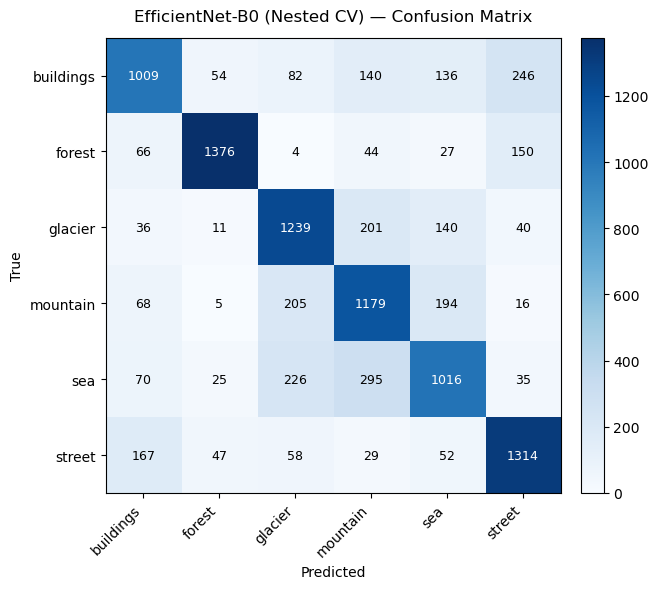

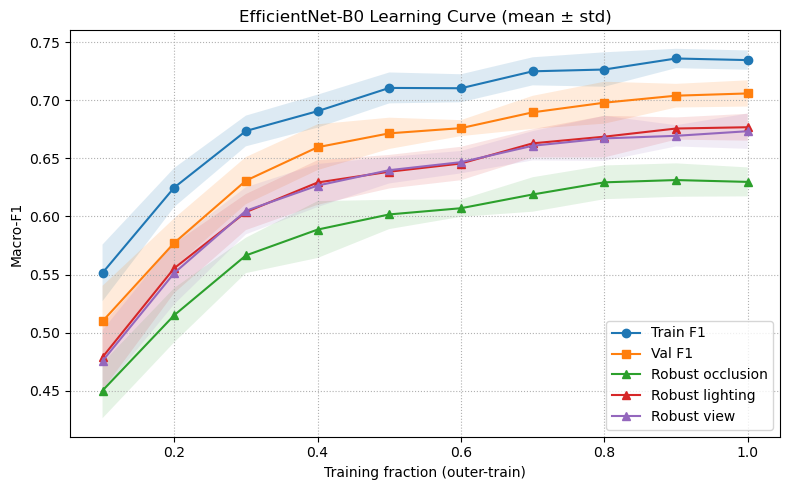

In [8]:
# Nested CV (10×3) for EfficientNet with train/eval/robust transforms
# - Inner: tune LR × WD using only outer-train
# - Outer: report per-fold metrics on outer-val
# - Robust eval on outer-val with robust_tfms
# - Learning curve with error band

import os, json, time, math, itertools, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from typing import Dict, List

from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import torchvision.models as tvm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# ---- prerequisites ----
assert "train_tfms" in globals() and "eval_tfms" in globals(), "Define train_tfms/eval_tfms first."
if "robust_tfms" not in globals(): robust_tfms = {}  # optional dict of name->transform

# dataset root
if "train_ds" in globals():
    base_root = getattr(getattr(train_ds, "dataset", train_ds), "root", None)
else:
    base_root = "subset_1667" if Path("subset_1667").exists() else "merged"
assert base_root and Path(base_root).exists(), f"Base dataset root not found: {base_root}"

base = datasets.ImageFolder(base_root, transform=None)
classes = base.classes
K = len(classes)
labels = np.array([y for _, y in base.samples], dtype=np.int64)
N = len(base)
idx_all = np.arange(N)

# ---- config ----
MODEL = "b0"                 # "b0" or "b2"
EPOCHS = 10                   # keep small for CV
BATCH_SIZE = 256
LABEL_SMOOTH = 0.05
FREEZE_BACKBONE_EPOCHS = 0
GRAD_CLIP = 1.0
NUM_WORKERS = 0
GRID_LR = [1e-3, 5e-3, 1e-2]       # inner search
GRID_WD = [3e-1]
LEARNING_FRACTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
SEED = 42

# ---- device/seed ----
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp = device.type == "cuda"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# ---- model builder ----
if MODEL == "b2":
    base_model = tvm.efficientnet_b2; Weights = tvm.EfficientNet_B2_Weights.IMAGENET1K_V1
else:
    base_model = tvm.efficientnet_b0; Weights = tvm.EfficientNet_B0_Weights.IMAGENET1K_V1

def build_model():
    m = base_model(weights=Weights)
    in_feat = m.classifier[-1].in_features
    m.classifier[-1] = nn.Linear(in_feat, K)
    return m.to(device)

def set_backbone_trainable(m, flag: bool):
    for name, p in m.named_parameters():
        p.requires_grad = True if name.startswith("classifier.") else flag

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

def make_loader(indices, tfm, shuffle):
    ds = Subset(datasets.ImageFolder(base_root, transform=tfm), indices)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses, preds, gts = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=amp):
            logits = model(xb); loss = criterion(logits, yb)
        losses.append(loss.item())
        preds.append(logits.argmax(1).detach().cpu().numpy())
        gts.append(yb.detach().cpu().numpy())
    y_pred = np.concatenate(preds); y_true = np.concatenate(gts)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return float(np.mean(losses)), acc, f1m, y_true, y_pred

def train_eval_once(lr, wd, tr_idx, va_idx):
    train_loader = make_loader(tr_idx, train_tfms, shuffle=True)
    val_loader   = make_loader(va_idx, eval_tfms,  shuffle=False)

    m = build_model()
    set_backbone_trainable(m, FREEZE_BACKBONE_EPOCHS == 0)
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=lr, weight_decay=wd)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=amp)

    best = (-1.0, None, None)  # f1, y_true, y_pred
    for epoch in range(1, EPOCHS + 1):
        if epoch == 1 and FREEZE_BACKBONE_EPOCHS > 0:
            set_backbone_trainable(m, False)
        if epoch == FREEZE_BACKBONE_EPOCHS + 1 and FREEZE_BACKBONE_EPOCHS > 0:
            set_backbone_trainable(m, True)
            opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
            sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS - FREEZE_BACKBONE_EPOCHS)

        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=amp):
                logits = m(xb); loss = criterion(logits, yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            if GRAD_CLIP:
                scaler.unscale_(opt); nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            scaler.step(opt); scaler.update()
        sch.step()

        _, va_acc, va_f1, y_true, y_pred = evaluate(m, val_loader)
        if va_f1 > best[0]:
            best = (va_f1, y_true, y_pred)
    return best[0], best[1], best[2], m.state_dict()  # best_f1, y_true, y_pred, weights

def plot_cm(cm, classes, title):
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(len(classes)), yticks=np.arange(len(classes)),
           xticklabels=classes, yticklabels=classes,
           ylabel="True", xlabel="Predicted", title=title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for i, j in itertools.product(range(len(classes)), range(len(classes))):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.tight_layout(); plt.show()

def stratified_subsample(indices, labels_all, frac, seed=SEED):
    if frac >= 1.0: return indices
    rng = np.random.default_rng(seed)
    take = []
    lab = labels_all[indices]
    for c in range(K):
        c_idx = indices[lab == c]
        if len(c_idx) == 0: continue
        n = max(1, int(math.ceil(len(c_idx) * frac)))
        pick = rng.choice(c_idx, size=min(n, len(c_idx)), replace=False)
        take.append(pick)
    return np.sort(np.concatenate(take, 0))

# ---- nested CV ----
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

outer_metrics = []
outer_preds_all = []
outer_true_all  = []
robust_metrics = defaultdict(list)

# ---- learning curve (train + val, mean ± std) ----
fracs = np.array(LEARNING_FRACTIONS, dtype=float)
lc_train_scores = {f: [] for f in fracs}
lc_val_scores   = {f: [] for f in fracs}
lc_robust_scores = {name: {f: [] for f in fracs} for name in robust_tfms.keys()}

for fold_id, (outer_tr_idx, outer_va_idx) in enumerate(outer_cv.split(idx_all, labels), 1):
    print(f"\n=== Outer fold {fold_id}/10 ===")
    # inner CV: choose LR, WD on outer-train only
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED + fold_id)
    best_cfg, best_score = None, -1.0
    for lr in GRID_LR:
        for wd in GRID_WD:
            scores = []
            for inner_tr_rel, inner_va_rel in inner_cv.split(outer_tr_idx, labels[outer_tr_idx]):
                inner_tr = outer_tr_idx[inner_tr_rel]
                inner_va = outer_tr_idx[inner_va_rel]
                f1, _, _, _ = train_eval_once(lr, wd, inner_tr, inner_va)
                scores.append(f1)
            m_f1 = float(np.mean(scores))
            print(f"  inner grid: LR={lr:.1e} WD={wd:.0e} -> f1m={m_f1:.4f}")
            if m_f1 > best_score:
                best_score = m_f1
                best_cfg = {"lr": lr, "wd": wd}
    print(f"Chosen (outer {fold_id}): {best_cfg}  inner-f1m={best_score:.4f}")

    # train on full outer-train with best hyperparams; eval on outer-val
    best_f1, y_true, y_pred, state = train_eval_once(best_cfg["lr"], best_cfg["wd"], outer_tr_idx, outer_va_idx)
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average="macro")
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(  y_true, y_pred, average="macro", zero_division=0)
    print(f"Outer fold {fold_id}: acc={acc:.4f}  f1m={f1m:.4f}")
    outer_metrics.append({"fold": fold_id, "acc": acc, "f1m": f1m, "prec": prec, "rec": rec, **best_cfg})
    outer_true_all.append(y_true); outer_preds_all.append(y_pred)

    # robust evals on outer-val
    for name, tfm in robust_tfms.items():
        r_loader = make_loader(outer_va_idx, tfm, shuffle=False)
        # rebuild model and load state to ensure same weights
        m = build_model(); m.load_state_dict(state); m.to(device)
        _, racc, rf1, _, _ = evaluate(m, r_loader)
        robust_metrics[name].append((racc, rf1))
        print(f"  [Robust:{name}] acc={racc:.4f}  f1m={rf1:.4f}")

    # learning curve on this outer fold with best hyperparams
    for frac in fracs:
        sub_idx = stratified_subsample(outer_tr_idx, labels, float(frac),
                                       seed=SEED + fold_id + int(frac*1000))
        _, _, _, state_sub = train_eval_once(best_cfg["lr"], best_cfg["wd"], sub_idx, outer_va_idx)

        m = build_model(); m.load_state_dict(state_sub); m.to(device)
        train_eval_loader = make_loader(sub_idx,     eval_tfms, shuffle=False)
        val_eval_loader   = make_loader(outer_va_idx, eval_tfms, shuffle=False)

        _, _, f1_train, _, _ = evaluate(m, train_eval_loader)
        _, _, f1_val,   _, _ = evaluate(m, val_eval_loader)
        lc_train_scores[float(frac)].append(f1_train)
        lc_val_scores[float(frac)].append(f1_val)

        # robustness on outer-val at this fraction
        for rname, rtfm in robust_tfms.items():
            r_loader = make_loader(outer_va_idx, rtfm, shuffle=False)
            _, _, f1_r, _, _ = evaluate(m, r_loader)
            lc_robust_scores[rname][float(frac)].append(f1_r)


# ---- aggregate ----
y_all_val = np.concatenate(outer_true_all)
y_all_pred = np.concatenate(outer_preds_all)
mean_acc = float(np.mean([m["acc"] for m in outer_metrics])); std_acc = float(np.std([m["acc"] for m in outer_metrics]))
mean_f1  = float(np.mean([m["f1m"] for m in outer_metrics])); std_f1  = float(np.std([m["f1m"] for m in outer_metrics]))

mean_prec = float(np.mean([m["prec"] for m in outer_metrics])); std_prec = float(np.std([m["prec"] for m in outer_metrics]))
mean_rec  = float(np.mean([m["rec"]  for m in outer_metrics])); std_rec  = float(np.std([m["rec"]  for m in outer_metrics]))

print("\n=== Nested CV summary (outer folds) ===")
print(f"Accuracy        mean={mean_acc:.4f}  std={std_acc:.4f}")
print(f"Macro-F1        mean={mean_f1:.4f}  std={std_f1:.4f}")
print(f"Macro-Precision mean={mean_prec:.4f} std={std_prec:.4f}")
print(f"Macro-Recall    mean={mean_rec:.4f}  std={std_rec:.4f}")


print("\nPer-fold results:")
for m in outer_metrics:
    print(f" fold {m['fold']:02d}: acc={m['acc']:.4f} f1m={m['f1m']:.4f} | LR={m['lr']:.1e} WD={m['wd']:.0e}")

if robust_metrics:
    print("\nRobustness (outer-val) summary:")
    for name, vals in robust_metrics.items():
        accs = [a for a, _ in vals]; f1s = [f for _, f in vals]
        print(f" {name:<10} acc mean={np.mean(accs):.4f} std={np.std(accs):.4f} | f1 mean={np.mean(f1s):.4f} std={np.std(f1s):.4f}")

print("\nClassification report (all outer validations):")
print(classification_report(y_all_val, y_all_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_all_val, y_all_pred)
plot_confusion_matrix(cm, classes, f"EfficientNet-{MODEL.upper()} (Nested CV) — Confusion Matrix")

# ---- learning curve plots (train, val, robust) ----
t_means = np.array([np.mean(lc_train_scores[f]) for f in fracs])
t_stds  = np.array([np.std( lc_train_scores[f]) for f in fracs])
v_means = np.array([np.mean(lc_val_scores[f])   for f in fracs])
v_stds  = np.array([np.std( lc_val_scores[f])   for f in fracs])

plt.figure(figsize=(8,5))
plt.plot(fracs, t_means, marker="o", label="Train F1")
plt.fill_between(fracs, t_means - t_stds, t_means + t_stds, alpha=0.15)
plt.plot(fracs, v_means, marker="s", label="Val F1")
plt.fill_between(fracs, v_means - v_stds, v_means + v_stds, alpha=0.15)

for rname, per_frac in lc_robust_scores.items():
    r_means = np.array([np.mean(per_frac[f]) if per_frac[f] else np.nan for f in fracs])
    r_stds  = np.array([np.std( per_frac[f]) if per_frac[f] else np.nan for f in fracs])
    plt.plot(fracs, r_means, marker="^", label=f"Robust {rname}")
    plt.fill_between(fracs, r_means - r_stds, r_means + r_stds, alpha=0.12)

plt.xlabel("Training fraction (outer-train)")
plt.ylabel("Macro-F1")
plt.title(f"EfficientNet-{MODEL.upper()} Learning Curve (mean ± std)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# ---- save summary ----
Path("artifacts").mkdir(exist_ok=True)

robust_lc = {
    name: {
        "fractions": fracs.tolist(),
        "mean_macro_f1": [float(np.nanmean([*per_frac[f]])) if per_frac[f] else None for f in fracs],
        "std_macro_f1":  [float(np.nanstd ([*per_frac[f]])) if per_frac[f] else None for f in fracs],
    }
    for name, per_frac in lc_robust_scores.items()
}

with open("artifacts/effnet_nestedcv_summary.json", "w") as f:
    json.dump({
        "model": f"efficientnet_{MODEL}",
        "outer_folds": 10,
        "inner_folds": 3,
        "grid": {"lr": GRID_LR, "wd": GRID_WD},
        "outer_metrics": outer_metrics,  
        "accuracy": {"mean": mean_acc, "std": std_acc},
        "macro_f1": {"mean": mean_f1, "std": std_f1},
        "macro_precision": {"mean": mean_prec, "std": std_prec},
        "macro_recall": {"mean": mean_rec, "std": std_rec},
        "learning_curve": {
            "fractions": fracs.tolist(),
            "train_mean_f1": t_means.tolist(),
            "train_std_f1":  t_stds.tolist(),
            "val_mean_f1":   v_means.tolist(),
            "val_std_f1":    v_stds.tolist()
        },
        "robust_learning_curves": robust_lc
    }, f, indent=2)
